Dataset Loaded Successfully! Shape: (205, 25)
Total Features after One-Hot Encoding: 64




,Evaluation Metric,Result Value
0,Mean Squared Error (MSE),"7,854,537.7724"
1,Root Mean Squared Error (RMSE),"2,802.5948"
2,R-Squared Score (R²),0.8884


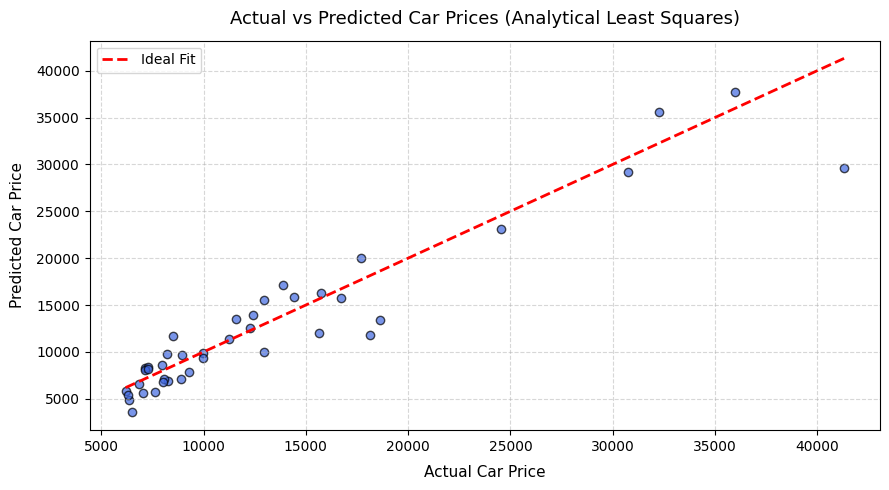

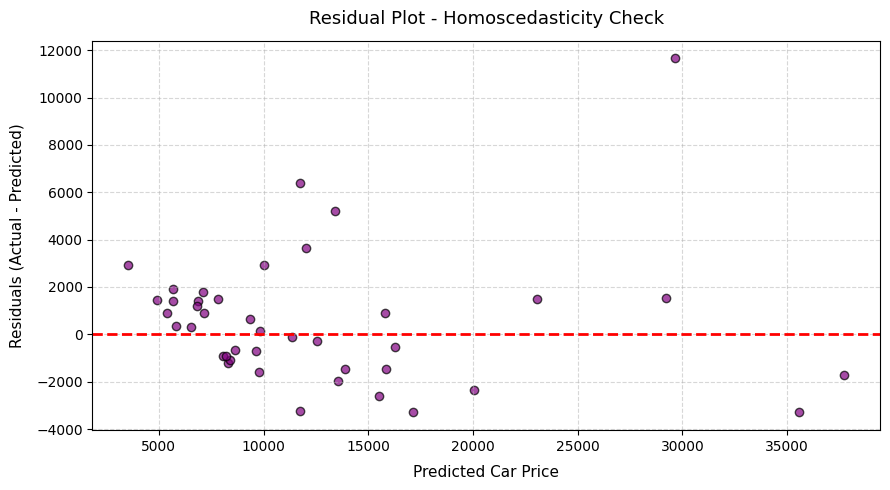

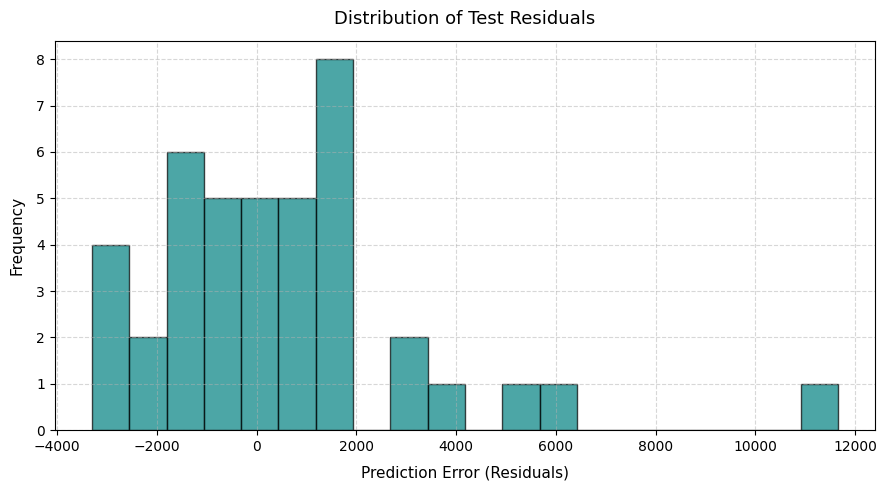

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Dataset directly from public URL
url = "https://raw.githubusercontent.com/rpizarrog/Analisis-Inteligente-de-datos/main/datos/CarPrice_Assignment.csv"
df = pd.read_csv(url)

# 2. Feature Extraction & Cleaning
if 'CarName' in df.columns:
    df['car_company'] = df['CarName'].apply(lambda x: str(x).split(' ')[0].lower())
    df = df.drop(columns=['CarName'])

if 'car_ID' in df.columns:
    df = df.drop(columns=['car_ID'])

df['car_company'] = df['car_company'].replace({
    'maxda': 'mazda', 'nissan': 'nissan', 'porcshce': 'porsche',
    'toyouta': 'toyota', 'vokswagen': 'volkswagen', 'vw': 'volkswagen'
})

y = df['price'].to_numpy()
X_df = df.drop(columns=['price'])
X_df = pd.get_dummies(X_df, drop_first=True, dtype=float)
X = X_df.to_numpy()

print(f"Dataset Loaded Successfully! Shape: {df.shape}")
print(f"Total Features after One-Hot Encoding: {X.shape[1]}")

# 3. Train-Test Split (80% Train, 20% Test)
rng = np.random.default_rng(42)
indices = rng.permutation(len(X))
split = int(0.8 * len(X))

X_train = X[indices[:split]]
X_test = X[indices[split:]]
y_train = y[indices[:split]]
y_test = y[indices[split:]]

# 4. Feature Scaling (Using population standard deviation ddof=0)
mean = X_train.mean(axis=0)
std = X_train.std(axis=0, ddof=0)
keep = std > 0

X_train = (X_train[:, keep] - mean[keep]) / std[keep]
X_test = (X_test[:, keep] - mean[keep]) / std[keep]

# Add bias intercept term
X_train = np.c_[np.ones(len(X_train)), X_train]
X_test = np.c_[np.ones(len(X_test)), X_test]

# 5. Model Training via Analytical Least Squares (No Scikit-Learn)
theta, residuals, rank, s = np.linalg.lstsq(X_train, y_train, rcond=None)

# 6. Predictions & Clean Metrics Table
test_preds = X_test @ theta
mse = np.mean((test_preds - y_test) ** 2)
rmse = np.sqrt(mse)
r2 = 1 - np.sum((y_test - test_preds) ** 2) / np.sum((y_test - y_test.mean()) ** 2)

metrics_table = pd.DataFrame({
    "Evaluation Metric": ["Mean Squared Error (MSE)", "Root Mean Squared Error (RMSE)", "R-Squared Score (R²)"],
    "Result Value": [f"{mse:,.4f}", f"{rmse:,.4f}", f"{r2:,.4f}"]
})

print("\n")
display(metrics_table)
print("\n")

# 7. Professional Visualizations with Proper Spacing & Padding
plt.figure(figsize=(9, 5))
plt.scatter(y_test, test_preds, color='royalblue', alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel("Actual Car Price", fontsize=11, labelpad=8)
plt.ylabel("Predicted Car Price", fontsize=11, labelpad=8)
plt.title("Actual vs Predicted Car Prices (Analytical Least Squares)", fontsize=13, pad=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

res = y_test - test_preds
plt.figure(figsize=(9, 5))
plt.scatter(test_preds, res, color='purple', alpha=0.7, edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Car Price", fontsize=11, labelpad=8)
plt.ylabel("Residuals (Actual - Predicted)", fontsize=11, labelpad=8)
plt.title("Residual Plot - Homoscedasticity Check", fontsize=13, pad=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(res, bins=20, color='teal', edgecolor='black', alpha=0.7)
plt.xlabel("Prediction Error (Residuals)", fontsize=11, labelpad=8)
plt.ylabel("Frequency", fontsize=11, labelpad=8)
plt.title("Distribution of Test Residuals", fontsize=13, pad=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()